## How to do Hypothesis Testing

#### Objectives:
* know the difference between a null and alternative hypothesis
* write our own set of hypothesis for testing


### Null Hypothesis

I claim that I can use mystical abilities to predict the outcome of coin flips.

You don't think I can.

How can we test it? We do an exprement in which I call 100 coin flips. I get 57 right. Am I special or not?

---

### Determining the Null and Alternative Hypothesis
Write the null and alternative hypothesis.

Null: I am not special; my true rate of flip prediction is 0.5. But even under this hypothesis, I could get 57 out of 100 right. So did i get lucky or am i mystical?

Alternative: My true rate of flip prediction is greater than 0.5.

The thing we are measuring from the experiment, or **test statistic**, is the number of correct flip predictions out of 100.

---

If the null hypothesis is correct, the test statistic is binomial distributed with parameters `n = 100` (number of flips) and `p = 0.5` (probability of balanced coin). That is, if we repeated the whole experiment many times, we would see such a distribution for all the results.

So if the null hypothesis is correct, how likely is it that I got 57 or more coin flips correct?

Before we check (really, before we do the experiment) we decide what would convince us that I have ESP. The choice of a cutoff at 5% probability is common. 

---

We have two outcomes, one with probability (p) and the other with probability (1-p) of happening event, we know the [binomial](https://en.wikipedia.org/wiki/Binomial_distribution?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML0232ENSkillsNetwork837-2023-01-01) [distribution](http://mathworld.wolfram.com/BinomialDistribution.html?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML0232ENSkillsNetwork837-2023-01-01) is the [right tool for this analysis](https://homepage.divms.uiowa.edu/~mbognar/applets/bin.html?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML0232ENSkillsNetwork837-2023-01-01).

In the case of the binomial distribution (histogram normal curve shape), which is discrete and not too complicated mathematically, we could just work out the probability. But in general we'll rely on some existing functionality such as scipy.stats.

In [1]:
from scipy.stats import binom
prob_getting_less_than_57 = binom.cdf(56, 100, 0.5)       # probability of getting 0 to 56 correct guesses in 100 coin tosses.
prob_getting_more_than_56 = 1 - prob_getting_less_than_57 # probability of getting more than 56 correct guesses in 100 coin tosses.

print(str(round(prob_getting_more_than_56 * 100, 2)) + "%")

9.67%


The probability of getting 57 or more correct prediction for a regular, non-magical human is about 9.7%. Since this is more than 5% (the standard alpha threshold), we are still in the zone of being lucky, so we CANNOT reject the null and conclude that I (probably) don't have mystical powers.

Conversely, we can figure out what the 95% cutoff is beforehand.


### Exercise

Find the number of coin flips a person would need to guess correctly for us to believe they're clairvoyant (supernatural).

In [2]:
print(binom.ppf(0.95,100,0.5) + 1)

59.0


Which means, one should get 59 tosses or more correct guesses to be considered clairvoyant. And we will say the person has predictive power with a confidence level of 95%.

---

### A More Specific Claim

So far so good. What if instead I said, "I'm not perfect, but I can predict coin tosses 60% of the time. Which is still good, which is still valuable."

What do we do in this case? Sure, we can do exactly what we did earlier and when I predict 57 times, we can reject my claim.

But what if I say, "Wait a minute. I said 60 and I got 57, that sounds pretty good to me."

Interpretation:
> "I happened to have a poor guessing day, and that's why my results aren't quite statistically significant!"

What do we say to that? The issue here is that there is no longer a single null hypothesis that we prove or disprove. Instead, **we have two competing hypotheses**:
* Hypothesis A: There is no predictive power
* Hypothesis B: There is a 60% predictive power

Each is a normal curve, with one centered at 50% and the other at 60%.

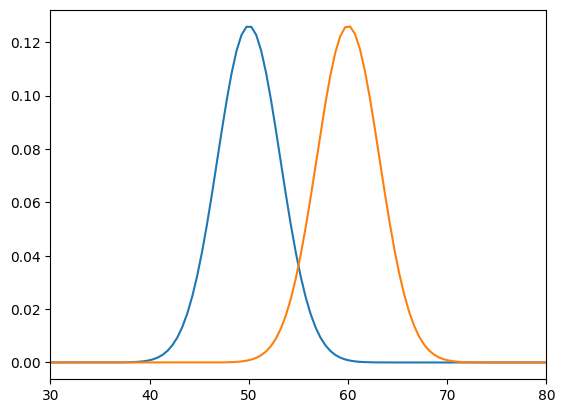

In [3]:
import math
from matplotlib import pyplot as plt
import numpy as np
from scipy import stats

mu = 50
variance = 10
sigma = math.sqrt(variance)
x = np.linspace(1, 100, 200)
plt.plot(x,stats.norm.pdf(x, mu, sigma))

mu = 60
variance = 10
sigma = math.sqrt(variance)
x = np.linspace(1, 100, 200)
plt.plot(x,stats.norm.pdf(x, mu, sigma))

plt.xlim(30,80)
plt.show()

**And 57 correct guesses falls within the 95% confidence of both the curves:**

In [4]:
print (1 - binom.cdf(57, 100, 0.5))
print (binom.cdf(57, 100, 0.6))

0.06660530960360678
0.3032601298434456


<BR><hr width="50%"><BR>
**Additional Notes**:

This is where the tutorial moves from "Is this person a fake?" to a more sophisticated "Which of these two versions of reality is more likely?"

In the first part of the study, we were only trying to debunk a claim. Now, we are trying to choose between two specific models.

**The Core Intention**: Comparing Two "Truths"

The intention of this section is to introduce Power and Overlapping Realities. Instead of just having one "Boring Fact" (Null) and a vague "Something Else" (Alternative), we now have two concrete, competing mathematical worlds.

* Hypothesis A (The Old Truth): A world where you are a normal human (50% success).

* Hypothesis B (The New Claim): A world where you are exactly as good as you say (60% success).

<BR><hr width="50%"><BR>

What now? There just isn't enough data to achieve a confidence of 95%. There are few things we can do.

<BR><hr width="50%"><BR>
**Additional Notes on what the above statement means.**:

"Not enough data to achieve 95% confidence" is the math's way of saying: "I see what you're trying to show me, but I need you to keep flipping so I can be sure it's not a fluke."

In Data Science projects (like the Airline or Laptop data), seeing a "p-value" of 0.09, don't necessarily mean giving up. It just mean, "I need a larger dataset to see if this trend is real."

In the world of data, a result that isn't Statistically Significant (like the 9.67%) doesn't always mean the effect isn't there — it just means the "Court of Math" doesn't have enough evidence to convict the Null Hypothesis yet.

When we run our Python code on a dataset, we aren't just getting a "Yes" or "No." We're actually getting one of these three situations:

* The **Breakthrough**: The p-value is 0.01. The evidence is overwhelming. We Reject the Null and celebrate our "New Truth."
* The **Dead End**    : The p-value is 0.50. We are exactly where the Null expected. There is clearly nothing special happening.
* The **"Gray Zone"** (Our Current Case): The p-value is 0.09. We're better than average, but not "weird" enough to prove it. This is where the tutorial says, "The story continues... more data and testing needed."

The "Gray Zone" is exactly where you—the expert—become valuable.


**How to Escape the Gray Zone**

When you find yourself stuck in that "9.67% probability" area, you have three professional moves:

|The Move	|What you do	|Why it works |
|--|--|--|
|Increase N	|Get more data (1,000 flips instead of 100).	|It "sharpens" the resolution of your test.|
|Control Noise	|Fix the environment (Use a "fair" machine to flip).	|It narrows the bell curve, making the signal clearer.|
|Change Alpha	|Decide that 10% is "Good enough" for this task.	|Sometimes, a 90% certainty is fine for low-risk decisions.|

<BR><hr width="50%"><BR>

So now, there are few things we can do.

#### 1) Decrease confidence (change alpha)

Since we have a claim at 50 and 60, we can pick the mid-point, which is 55. We can say if I can predict over 55, then I have predictive power. This would mean that we have decreased our confidence level.

In [5]:
print (1 - binom.cdf(55, 100, 0.5))
print (binom.cdf(54, 100, 0.6))

0.13562651203691767
0.13109045261974825


**At an 87% percent confidence level, we can say that I have some predictive power, since I got 57 tosses correct.**

Not ideal; we picked a number, which is prone to bias, rather than a confidence interval.


#### 2) Be biased (control noise)

But it is not neccessary that we bias the two hypotheses equally and pick the midpoint the way we did. The cut-off point can be anywhere. Currently, our error margins are even. The chance that someone has predictive power and we say no is 13% and the chance that someone has no power and we say they do is also 13%. As we change the cutoff, one error goes down and the other goes way up.

For example, if we stuck with the original 95% on a coin being fair:

In [6]:
binom.ppf(0.95, 100, 0.5) #this is the inverse of the cdf functions above

np.float64(58.0)

Then our cutoff is 58. Our two errors will be:

In [7]:
print (1-binom.cdf(58, 100, 0.5))
print (binom.cdf(58, 100, 0.6))

0.04431304005703374
0.3774673238778288


5% chance someone has no power and we say they do. But a 38% chance someone has predictive power and we say no. Which depending on the problem might be exactly what we want. These two types of errors are called Type I and Type II. And we have the choice of biasing against one or the other. 

#### 3) Increase sample size (increase n)

The best scenario though is to increase the sample size. Imagine what happens we did 1000 tosses instead of 100.


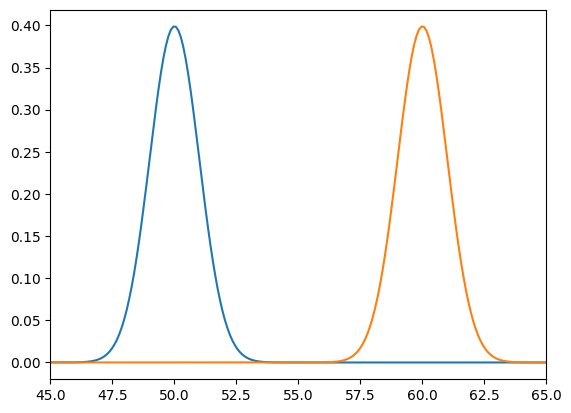

In [8]:
mu = 50
variance = 1
sigma = math.sqrt(variance)
x = np.linspace(1, 100, 1000)
plt.plot(x,stats.norm.pdf(x, mu, sigma))

mu = 60
variance = 1
sigma = math.sqrt(variance)
x = np.linspace(1, 100, 1000)
plt.plot(x,stats.norm.pdf(x, mu, sigma))

plt.xlim(45,65)
plt.show()

The two normal curves are completely separated now.

In [9]:
print (binom.ppf(0.95,1000,0.5))
print (binom.ppf(0.05,1000,0.6))

526.0
574.0


---

### Exercise

What are our errors now?

---

In [10]:
print (1-binom.cdf(550, 1000, 0.5))
print (binom.cdf(550, 1000, 0.6))

0.0006958707972110068
0.0007412028990059854


**With a cutoff of 550, both our errors come down to under 0.1%.**